# Lesson 5: Tools

## *Giving the Agent Hands*

---

### Where We Are

In Lesson 4, our LLM read a customer message and classified it into a department. Impressive - but notice what it could *not* do. If the customer asked "What is the weather in Tokyo?", the LLM would have to guess or refuse. It has no way to look things up.

The LLM is a brain in a jar. It can think, but it cannot reach into the outside world.

---

### What Tools Solve

**Tools** are Python functions the LLM can choose to call. They give the agent the ability to:
- Look up live data (weather, stock prices, database records)
- Take action (send an email, create a ticket, write a file)
- Access information it was never trained on

---

### The Mental Model

> **Think of a hotel concierge.**
>
> A guest walks up and asks: "What is the weather like today, and how crowded is the city?" The concierge cannot answer from memory. But they have resources at their desk - a weather app on their screen and a city statistics directory.
>
> They decide: "I need two lookups." They check the weather app, note the answer, then pull up the city stats, note that answer, and combine both into a response for the guest.
>
> If the guest instead asks "Where is the elevator?" - the concierge just answers. No lookup needed.
>
> The LLM is the concierge. The tools are the apps and directories on their desk. The concierge decides *which* resource to check, *when*, and *how many times* - then delivers a unified answer.

---

### What We Will Build

Exactly that concierge - an agent with access to a weather service and a population directory. It decides which to consult based on the question:

| Question | Tools Called | Final Answer |
|:---|:---|:---|
| "Weather in Tokyo?" | `get_weather("tokyo")` | "80F, Humid" |
| "Weather and population of London?" | `get_weather("london")`, `get_population("london")` | Combined answer |
| "What is 2 + 2?" | *None* | "4" (LLM answers directly) |

```
START -> agent (LLM) -> [needs a tool?]
                           |
                +----------+----------+
                |                     |
               END              tools (execute)
                                     |
                              agent (LLM) -> ... (loop until done)
```

---

## Step 1: Setup

Same dependencies as Lesson 4, plus `langchain-core` which provides the `@tool` decorator.

In [1]:
!pip install -q -U langgraph langchain-openai langchain-core


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sk72\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
except ImportError:
    from dotenv import load_dotenv
    load_dotenv(override=True)

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

---

## Step 2: Define Tools

A tool is a regular Python function with a `@tool` decorator. The decorator does two things:
1. Registers the function so LangGraph can execute it
2. Exposes the function's **name**, **docstring**, and **argument types** to the LLM

> **Critical**: The docstring is what the LLM reads to decide whether to use a tool. Think of it as the tool's job description. If you write "Does stuff" the LLM will not know when to call it. Be specific.

| Tool | What It Does | Input |
|:---|:---|:---|
| `get_weather` | Returns current temperature and conditions | `city: str` |
| `get_population` | Returns approximate population | `city: str` |

In [4]:
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city. Returns temperature and conditions."""
    # In production, this would call a weather API like OpenWeatherMap
    weather_data = {
        "new york": "72F, Sunny",
        "london": "58F, Cloudy",
        "tokyo": "80F, Humid",
    }
    return weather_data.get(city.lower(), f"Weather data not available for {city}")


@tool
def get_population(city: str) -> str:
    """Get the approximate population of a given city."""
    population_data = {
        "new york": "8.3 million",
        "london": "8.9 million",
        "tokyo": "13.9 million",
    }
    return population_data.get(city.lower(), f"Population data not available for {city}")


# Collect tools into a list - we will hand this list to the LLM
tools = [get_weather, get_population]

---

## Step 3: Bind Tools to the LLM

In Lesson 4, we created a plain `ChatOpenAI` and gave it instructions via a system prompt. Now we go further: `bind_tools()` hands the LLM a **catalog** of available resources.

> Like placing the weather app and city directory on the concierge's desk. They now *know* these resources exist. Whether they actually use them depends on what the guest asks.

The LLM does not automatically use tools - it only calls one when it decides the question requires external data.

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

---

## Step 4: Define State and the Agent Node

Our State is simpler than Lesson 4 - we only need `messages`. The LLM communicates tool requests and results through the message list itself.

The agent node calls the LLM. If the LLM needs a tool, its response will contain a `tool_calls` field. If it has enough info, it responds with plain text.

In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


def agent(state: State):
    """The thinking node. Calls the LLM which may or may not request tools."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

---

## Step 5: The Routing Decision

After the agent node runs, we need to decide: did the LLM request a tool call, or did it produce a final answer?

This is the same conditional edge pattern from Lessons 2 and 4. The difference: instead of checking a `department` field, we inspect the LLM's response for `tool_calls`.

| LLM Response Contains | Route To | Why |
|:---|:---|:---|
| `tool_calls` (non-empty) | `tools` node | LLM needs external data |
| Plain text | `END` | LLM has enough info, done |

> This creates a **loop** (Lesson 3): agent -> tools -> agent -> tools -> ... -> agent -> END. The loop runs until the LLM stops requesting tools.

In [7]:
def should_use_tools(state: State) -> str:
    """Check if the LLM wants to call a tool."""
    last_message = state["messages"][-1]
    # If the LLM returned tool calls, route to the tool executor
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    # Otherwise, the LLM gave a direct answer
    return END

---

## Step 6: Assemble the Graph

Two nodes, one conditional edge, one loop-back edge.

LangGraph provides a built-in `ToolNode` that handles executing tool calls automatically. It reads `tool_calls` from the last message, runs the corresponding functions, and appends the results back to State as tool messages.

In [8]:
workflow = StateGraph(State)

# Register nodes
workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode(tools))  # Built-in tool executor

# Entry point
workflow.add_edge(START, "agent")

# After agent: either use tools or finish
# Path map shows both possible destinations for the renderer
workflow.add_conditional_edges(
    "agent",
    should_use_tools,
    {"tools": "tools", END: END}
)

# After tools run, always go back to agent (so it can process the results)
workflow.add_edge("tools", "agent")

app = workflow.compile()

---

## Step 7: Test the Agent

Three scenarios that demonstrate different tool usage patterns:

| Scenario | Expected Behavior |
|:---|:---|
| Weather question | LLM calls `get_weather`, uses result to answer |
| Multi-fact question | LLM calls both tools, combines results |
| Simple math | LLM answers directly, no tools needed |

In [9]:
# Scenario 1: Question that requires ONE tool
result = app.invoke({"messages": [("human", "What is the weather like in Tokyo?")]})
print("Q: What is the weather like in Tokyo?")
print(f"A: {result['messages'][-1].content}")
print("---")

Q: What is the weather like in Tokyo?
A: The weather in Tokyo is currently 80°F and humid.
---


In [10]:
# Scenario 2: Question that requires BOTH tools (multi-tool call)
result = app.invoke({"messages": [("human", "Tell me the weather and population of London.")]})
print("Q: Tell me the weather and population of London.")
print(f"A: {result['messages'][-1].content}")
print("---")

Q: Tell me the weather and population of London.
A: The current weather in London is 58°F and cloudy. The approximate population of London is 8.9 million.
---


In [11]:
# Scenario 3: Question that needs NO tools - LLM answers from its training
result = app.invoke({"messages": [("human", "What is 2 + 2?")]})
print("Q: What is 2 + 2?")
print(f"A: {result['messages'][-1].content}")

Q: What is 2 + 2?
A: 2 + 2 equals 4.


---

## Step 8: Visualize the Graph

Notice the loop between `agent` and `tools`. The agent keeps calling tools until it has enough information, then exits to END.

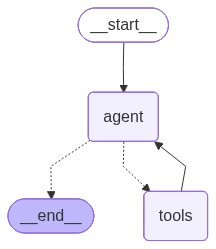

In [13]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

---

## Summary

### What Changed from Lesson 4

| Lesson 4 (LLM Node) | Lesson 5 (Tools) |
|:---|:---|
| LLM classifies and routes | LLM decides *and acts* on its own |
| Single LLM call, one-shot | Loop: LLM calls tools repeatedly until done |
| Output constrained to one word | Output is a full natural language answer |
| No external data access | Can reach into the outside world |

---

### The ReAct Pattern

What we built is formally called **ReAct** (Reason + Act). Here is how each iteration maps:

```
REASON:   LLM reads the question -> "I need weather data for Tokyo"
ACT:      LLM requests tool call -> get_weather("tokyo")
OBSERVE:  Tool returns "80F, Humid" -> fed back to LLM as a message
REASON:   LLM reads the result -> "I have enough info to answer"
RESPOND:  LLM produces final text -> graph exits to END
```

| ReAct Step | LangGraph Component | What Happens |
|:---|:---|:---|
| **Reason** | `agent` node | LLM decides what to do next |
| **Act** | `tools` node (ToolNode) | Executes the chosen function |
| **Observe** | Edge: `tools -> agent` | Result flows back into messages |
| **Repeat** | Conditional edge loop | Until LLM stops requesting tools |

---

### API Reference

| Component | Purpose |
|:---|:---|
| `@tool` decorator | Registers a function as LLM-callable |
| `llm.bind_tools(tools)` | Gives the LLM its tool catalog |
| `ToolNode(tools)` | Built-in node that executes tool calls |
| `message.tool_calls` | How you detect the LLM wants to use a tool |

---

### Key Takeaways

> 1. Tools are Python functions the LLM can *choose* to call
> 2. The docstring is the tool's resume - write it clearly and specifically
> 3. `bind_tools()` gives the LLM awareness; `ToolNode` does the execution
> 4. The agent-tool loop is the ReAct pattern: Reason -> Act -> Observe -> Repeat
> 5. The agent may call zero, one, or multiple tools per question

---

**Next Lesson**: The agent can now think and act autonomously. But what if it is about to do something dangerous - delete a file, send an email, charge a credit card? Lesson 6 introduces human-in-the-loop: approval gates that pause execution before risky actions.